In [11]:
import numpy as np 
from scipy import stats
import pandas as pd
import seaborn as sns 

In [12]:
#Importing all packages needed for matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch 


In [13]:
#Creating all the palette that we will need
palette_1 = ["#f72585", "#b5179e", "#7A0CC3", "#560bad", "#330A92", "#3f37c9", "#4361ee", "#4895ef", "#4cc9f0"]
palette_2 = ["#2C7B7B", "#004D4A", "#D02748", "#F9E03B", "#F0C808", "#D5A2D5", "#3E2A63", "#6BC6D3", "#007BA8"]


sns.set_theme(context="notebook", palette=palette_2, style="darkgrid")

In [14]:
#Importing all the libraries and tools that we need for sklearn
import sklearn 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

In [15]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
#Reading our CSV file 
df=pd.read_csv(r"C:/Users/samsung/fish_clustering_visualization/fish_data.csv")

In [17]:
df.head()

,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31


In [18]:
df.describe()

,length,weight,w_l_ratio
count,4080.000000,4080.000000,4080.000000
mean,17.353544,3.739875,0.252782
std,7.114684,1.040365,0.123046
min,6.360000,2.050000,0.080000
25%,11.327500,3.070000,0.170000
50%,17.350000,3.310000,0.190000
75%,22.585000,4.100000,0.340000
max,33.860000,6.290000,0.640000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   species    4080 non-null   object 
 1   length     4080 non-null   float64
 2   weight     4080 non-null   float64
 3   w_l_ratio  4080 non-null   float64
dtypes: float64(3), object(1)
memory usage: 127.6+ KB


In [20]:
df.isnull().sum()

species      0
length       0
weight       0
w_l_ratio    0
dtype: int64

In [21]:
df.duplicated().sum()

109

In [22]:
df.drop_duplicates(inplace=True)

In [24]:
df.shape #no brackets involved

(3971, 4)

In [26]:
X = df.drop("species", axis=1) #dataframe without any species column
y = df.species #dataframe with only species column

#Calculating ZScores to check if there are any outliners
zscores = pd.DataFrame(stats.zscore(X)) 
print("Descriptive Statistics of our table X:")
display(zscores.describe().round(3))

Descriptive Statistics of our table X:


,length,weight,w_l_ratio
count,3971.000,3971.000,3971.000
mean,0.000,0.000,0.000
std,1.000,1.000,1.000
min,-1.554,-1.629,-1.404
25%,-0.846,-0.639,-0.670
50%,0.003,-0.407,-0.507
75%,0.736,0.350,0.717
max,2.339,2.485,3.163


There is a completion of basic data cleaning at this point and we have successfully ensured that the datasets have: 
    - Removed any potential null values in the data
    - Removed any duplicated values 
    - Checked for possible outliners involved in the data
    - Checked for possible descriptive statistics of all data 
By doing so, we are ensuring that the data that we have is containing only relevant pieces of data that is very important in the field of data science.

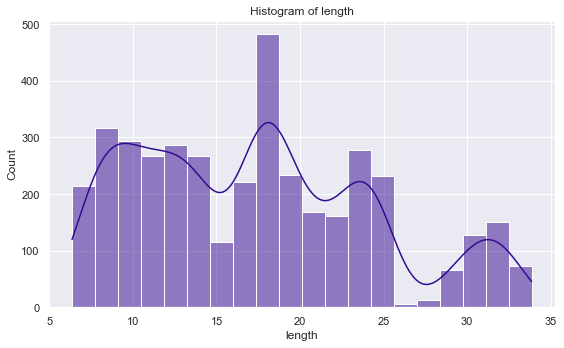

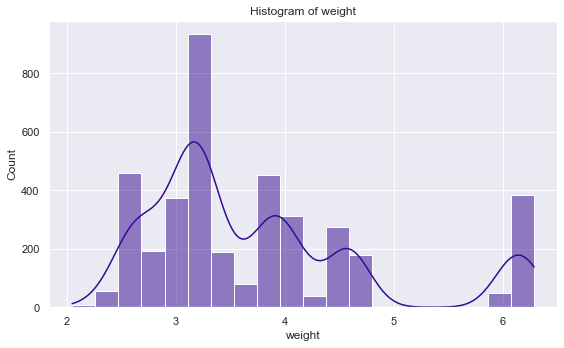

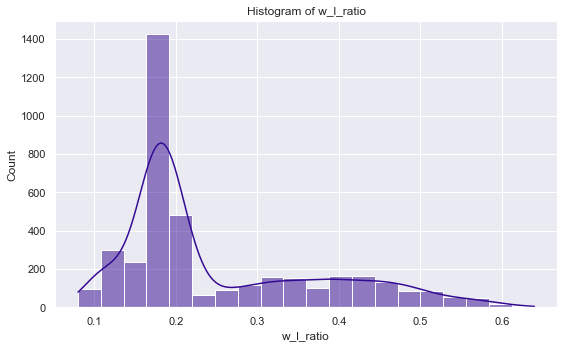

In [28]:
for columns in X:
    plt.figure(figsize=(8,5))
    sns.histplot(data=df,x=columns,kde=True, bins=20, color=palette_1[4])
    plt.title(f"Histogram of {columns}")

    plt.tight_layout()
    plt.show()

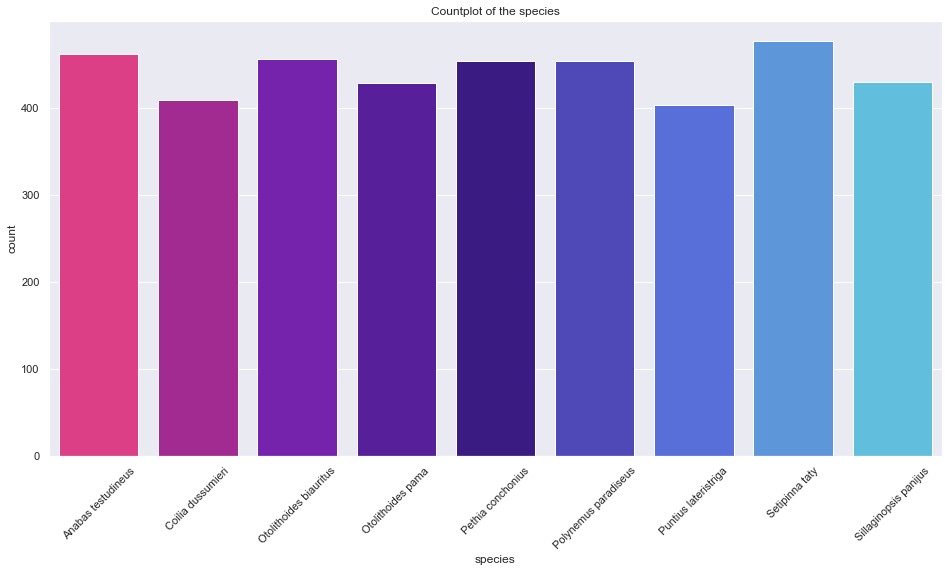

In [29]:
#Generating a count plot with the dataset Y
plt.figure(figsize=(16,8))
sns.countplot(data=df, x="species", palette=palette_1)
plt.title(f"Countplot of the species")
plt.xticks(rotation=45)
plt.show()

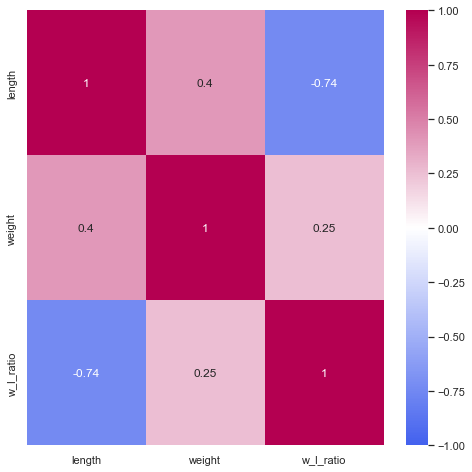

In [47]:
colors=["#4361EE", "#FFFFFF", "#B40051"]
cmap = LinearSegmentedColormap.from_list("custom_maps", colors)
corr_df = df.select_dtypes(include="number").corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr_df, cmap=cmap, center=0, vmin=-1, annot=True)
plt.show()

In [ ]:
#Instantiating a Scaler
scaler = MinMaxScaler()

#Fitting all values of X into a Scaler
X_scaled = scaler.fit_transform(X)